In [7]:
import pandas as pd

# Load your uploaded excel file
df = pd.read_excel('/content/Online Retail.xlsx')

# Look at the first 5 rows and a summary of columns
print("--- First 5 Rows ---")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

--- First 5 Rows ---
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   D

In [8]:
# Check total count of missing (null) values per column
print("--- Missing Values Count ---")
print(df.isnull().sum())



--- Missing Values Count ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [9]:
# Calculate the percentage of missing data
print("\n--- Percentage of Missing Data ---")
print((df.isnull().sum() / len(df)) * 100)


--- Percentage of Missing Data ---
InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


In [10]:
# Drop rows where CustomerID is NaN (missing)
df_clean = df.dropna(subset=['CustomerID'])

# Check the new size of our dataset
print(f"Original rows: {df.shape[0]}")
print(f"Rows left after dropping missing CustomerIDs: {df_clean.shape[0]}")

Original rows: 541909
Rows left after dropping missing CustomerIDs: 406829


In [11]:
# Check the minimum and maximum values for numeric columns
print(df_clean[['Quantity', 'UnitPrice']].describe())

            Quantity      UnitPrice
count  406829.000000  406829.000000
mean       12.061303       3.460471
std       248.693370      69.315162
min    -80995.000000       0.000000
25%         2.000000       1.250000
50%         5.000000       1.950000
75%        12.000000       3.750000
max     80995.000000   38970.000000


In [12]:
# 1. Look at a statistical summary of the Quantity column
print("--- Quantity Column Summary ---")
print(df_clean['Quantity'].describe())

# 2. Count exactly how many rows have a negative quantity
negative_rows = df_clean[df_clean['Quantity'] < 0]
print(f"\nNumber of rows with negative quantities: {len(negative_rows)}")

# 3. Look at a few examples of these negative transactions
print("\n--- Examples of Negative Quantity Rows ---")
print(negative_rows[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head())

--- Quantity Column Summary ---
count    406829.000000
mean         12.061303
std         248.693370
min      -80995.000000
25%           2.000000
50%           5.000000
75%          12.000000
max       80995.000000
Name: Quantity, dtype: float64

Number of rows with negative quantities: 8905

--- Examples of Negative Quantity Rows ---
    InvoiceNo StockCode                       Description  Quantity  UnitPrice
141   C536379         D                          Discount        -1      27.50
154   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS        -1       4.65
235   C536391     22556    PLASTERS IN TIN CIRCUS PARADE        -12       1.65
236   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES        -24       0.29
237   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES        -24       0.29


In [13]:
# 1. Isolate successful sales transactions
df_sales = df_clean[df_clean['Quantity'] > 0]

# 2. Isolate return/cancellation transactions
df_returns = df_clean[df_clean['Quantity'] < 0]

# 3. Double-check our numbers to make sure it worked perfectly
print("--- Data Pipeline Split Complete ---")
print(f"Total rows in Clean Sales Dataset (df_sales): {df_sales.shape[0]}")
print(f"Total rows in Returns Dataset (df_returns): {df_returns.shape[0]}")

# 4. Check if the minimum quantity in df_sales is now safely above 0
print(f"\nMinimum quantity in df_sales is now: {df_sales['Quantity'].min()}")

--- Data Pipeline Split Complete ---
Total rows in Clean Sales Dataset (df_sales): 397924
Total rows in Returns Dataset (df_returns): 8905

Minimum quantity in df_sales is now: 1


In [14]:
# 1. Convert InvoiceDate from text to a proper datetime format
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])

# 2. Check the new data type of the InvoiceDate column
print("--- Data Type Verification ---")
print(f"New data type for InvoiceDate: {df_sales['InvoiceDate'].dtype}")

# 3. Let's extract the minimum and maximum dates to see our timeframe
min_date = df_sales['InvoiceDate'].min()
max_date = df_sales['InvoiceDate'].max()

print(f"\nDataset Timeframe: From {min_date} to {max_date}")

--- Data Type Verification ---
New data type for InvoiceDate: datetime64[ns]

Dataset Timeframe: From 2010-12-01 08:26:00 to 2011-12-09 12:50:00


/tmp/ipykernel_1267/2890260705.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])


In [15]:
# 1. Create the TotalSpend column
df_sales['TotalSpend'] = df_sales['Quantity'] * df_sales['UnitPrice']

# 2. View the first few rows to verify the calculation worked
print("--- New Column Verified ---")
print(df_sales[['Quantity', 'UnitPrice', 'TotalSpend']].head())

# 3. Calculate the total net revenue generated in this dataset
total_revenue = df_sales['TotalSpend'].sum()
print(f"\n💰 Total Net Revenue in Dataset: ${total_revenue:,.2f}")

--- New Column Verified ---
   Quantity  UnitPrice  TotalSpend
0         6       2.55       15.30
1         6       3.39       20.34
2         8       2.75       22.00
3         6       3.39       20.34
4         6       3.39       20.34

💰 Total Net Revenue in Dataset: $8,911,407.90


/tmp/ipykernel_1267/3130154520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales['TotalSpend'] = df_sales['Quantity'] * df_sales['UnitPrice']


In [16]:
# 1. Group the data by CustomerID and sum up their TotalSpend
customer_revenue = df_sales.groupby('CustomerID')['TotalSpend'].sum().reset_index()

# 2. Rename the column so it's clean and clear
customer_revenue = customer_revenue.rename(columns={'TotalSpend': 'TotalCustomerSpend'})

# 3. Sort the customers to see who spent the most money
top_customers = customer_revenue.sort_values(by='TotalCustomerSpend', ascending=False)

print("--- Top 5 Highest Spending Customers ---")
print(top_customers.head())

print(f"\nTotal unique customers analyzed: {customer_revenue.shape[0]}")

--- Top 5 Highest Spending Customers ---
      CustomerID  TotalCustomerSpend
1690     14646.0           280206.02
4202     18102.0           259657.30
3729     17450.0           194550.79
3009     16446.0           168472.50
1880     14911.0           143825.06

Total unique customers analyzed: 4339


In [17]:
# 1. Calculate Average Spend per Customer
avg_spend = customer_revenue['TotalCustomerSpend'].mean()

# 2. Find the top 3 countries by total sales volume
top_countries = df_sales.groupby('Country')['TotalSpend'].sum().nlargest(3)

# 3. Print the final summary dashboard
print("=============================================")
print("   RESUME PROJECT METRICS DASHBOARD          ")
print("=============================================")
print(f"Total Successful Sales Rows:   {df_sales.shape[0]:,}")
print(f"Total Returned/Canceled Rows:  {df_returns.shape[0]:,}")
print(f"Total Unique Customers:        {customer_revenue.shape[0]:,}")
print(f"Total Store Net Revenue:       ${df_sales['TotalSpend'].sum():,.2f}")
print(f"Average Lifetime Value (LTV):  ${avg_spend:,.2f}")
print("\n--- Top 3 Generating Countries ---")
for country, rev in top_countries.items():
    print(f"{country}: ${rev:,.2f}")
print("=============================================")

   RESUME PROJECT METRICS DASHBOARD          
Total Successful Sales Rows:   397,924
Total Returned/Canceled Rows:  8,905
Total Unique Customers:        4,339
Total Store Net Revenue:       $8,911,407.90
Average Lifetime Value (LTV):  $2,053.79

--- Top 3 Generating Countries ---
United Kingdom: $7,308,391.55
Netherlands: $285,446.34
EIRE: $265,545.90


/tmp/ipykernel_1267/1873679728.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


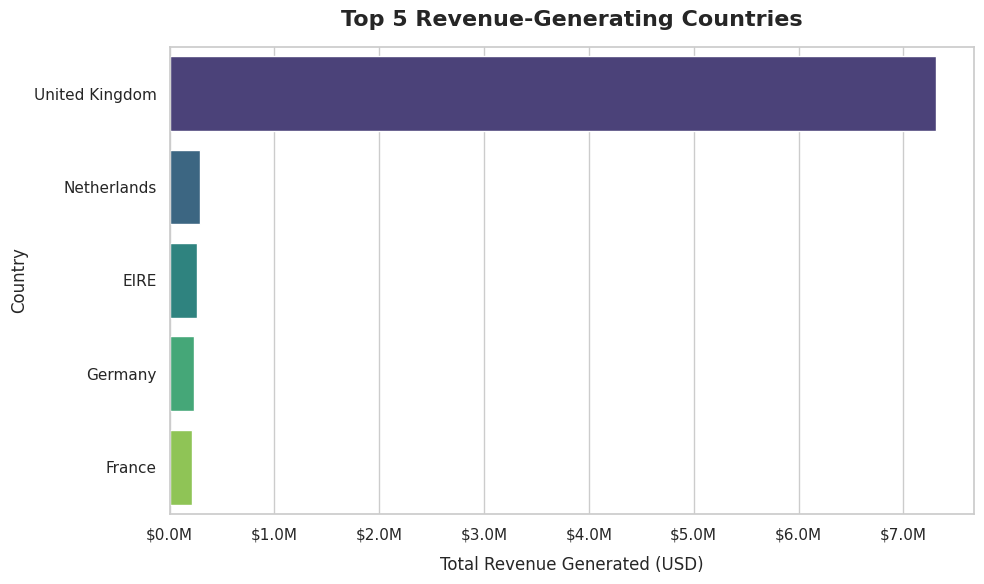

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by country and calculate total spend
country_spend = df_sales.groupby('Country')['TotalSpend'].sum().reset_index()

# 2. Grab the top 5 countries to keep the chart clean and scannable
top_5_countries = country_spend.nlargest(5, 'TotalSpend')

# 3. Set up the plotting environment styling
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Create the horizontal bar plot
ax = sns.barplot(
    x='TotalSpend',
    y='Country',
    data=top_5_countries,
    palette='viridis'
)

# 5. Format the x-axis numbers to look like millions of dollars ($M)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x*1e-6:,.1f}M"))

# 6. Customize labels and titles for a professional look
plt.title('Top 5 Revenue-Generating Countries', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Revenue Generated (USD)', fontsize=12, labelpad=10)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()

# 7. Display the final visualization
plt.show()

/tmp/ipykernel_1267/2158035429.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales['InvoiceMonth'] = df_sales['InvoiceDate'].dt.to_period('M').astype(str)


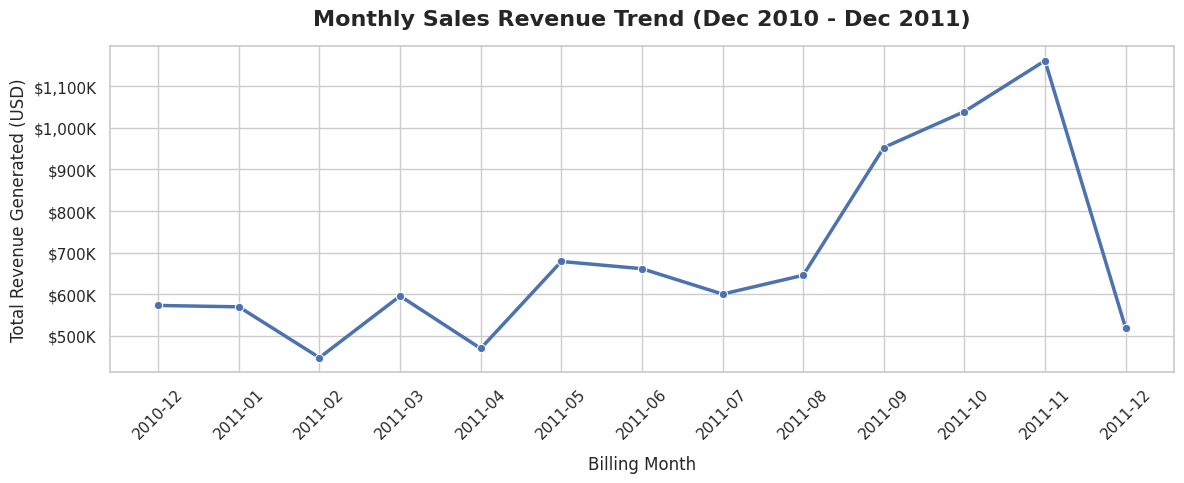

--- Exact Monthly Breakdown ---
InvoiceMonth  TotalSpend
     2010-12  572713.890
     2011-01  569445.040
     2011-02  447137.350
     2011-03  595500.760
     2011-04  469200.361
     2011-05  678594.560
     2011-06  661213.690
     2011-07  600091.011
     2011-08  645343.900
     2011-09  952838.382
     2011-10 1039318.790
     2011-11 1161817.380
     2011-12  518192.790


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract Year-Month from InvoiceDate (Creates a string format like '2010-12')
df_sales['InvoiceMonth'] = df_sales['InvoiceDate'].dt.to_period('M').astype(str)

# 2. Group by the new Month column and calculate total monthly spend
monthly_revenue = df_sales.groupby('InvoiceMonth')['TotalSpend'].sum().reset_index()

# 3. Plot the monthly trend line
plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

# Create a line plot with markers at each month
ax = sns.lineplot(
    x='InvoiceMonth',
    y='TotalSpend',
    data=monthly_revenue,
    marker='o',
    color='b',
    linewidth=2.5
)

# Format the y-axis to read cleanly in hundred-thousands/millions ($K/$M)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"${x*1e-3:,.0f}K"))

# Title and labels
plt.title('Monthly Sales Revenue Trend (Dec 2010 - Dec 2011)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Billing Month', fontsize=12, labelpad=10)
plt.ylabel('Total Revenue Generated (USD)', fontsize=12)
plt.xticks(rotation=45) # Rotate month names so they don't overlap
plt.tight_layout()

# Show the trend chart
plt.show()

# 4. Print the exact monthly breakdown table
print("--- Exact Monthly Breakdown ---")
print(monthly_revenue.to_string(index=False))

In [20]:
# Create a pivot table: Months as rows, Countries as columns, summing up TotalSpend
country_trends = df_sales.pivot_table(
    index='InvoiceMonth',
    columns='Country',
    values='TotalSpend',
    aggfunc='sum'
).fillna(0)

# Isolate just the top 3 countries we discovered earlier
top_3_trends = country_trends[['United Kingdom', 'Netherlands', 'EIRE']]

print("--- Month-by-Month Revenue for Top 3 Countries ---")
print(top_3_trends)

--- Month-by-Month Revenue for Top 3 Countries ---
Country       United Kingdom  Netherlands      EIRE
InvoiceMonth                                       
2010-12           498661.850      8784.48   8813.88
2011-01           442190.060     26611.16  21904.19
2011-02           355655.630     23011.91  10126.52
2011-03           467198.590     22416.49  21674.36
2011-04           409559.141      2976.56   7570.50
2011-05           551568.820     29185.88  15982.19
2011-06           524915.480     26858.09  19835.99
2011-07           485612.251        26.02  40905.15
2011-08           498453.320     40327.81  16967.38
2011-09           796780.272     26937.26  40995.49
2011-10           824766.220     40708.65  24317.92
2011-11           980645.750     25874.01  29473.41
2011-12           472384.170     11728.02   6978.92


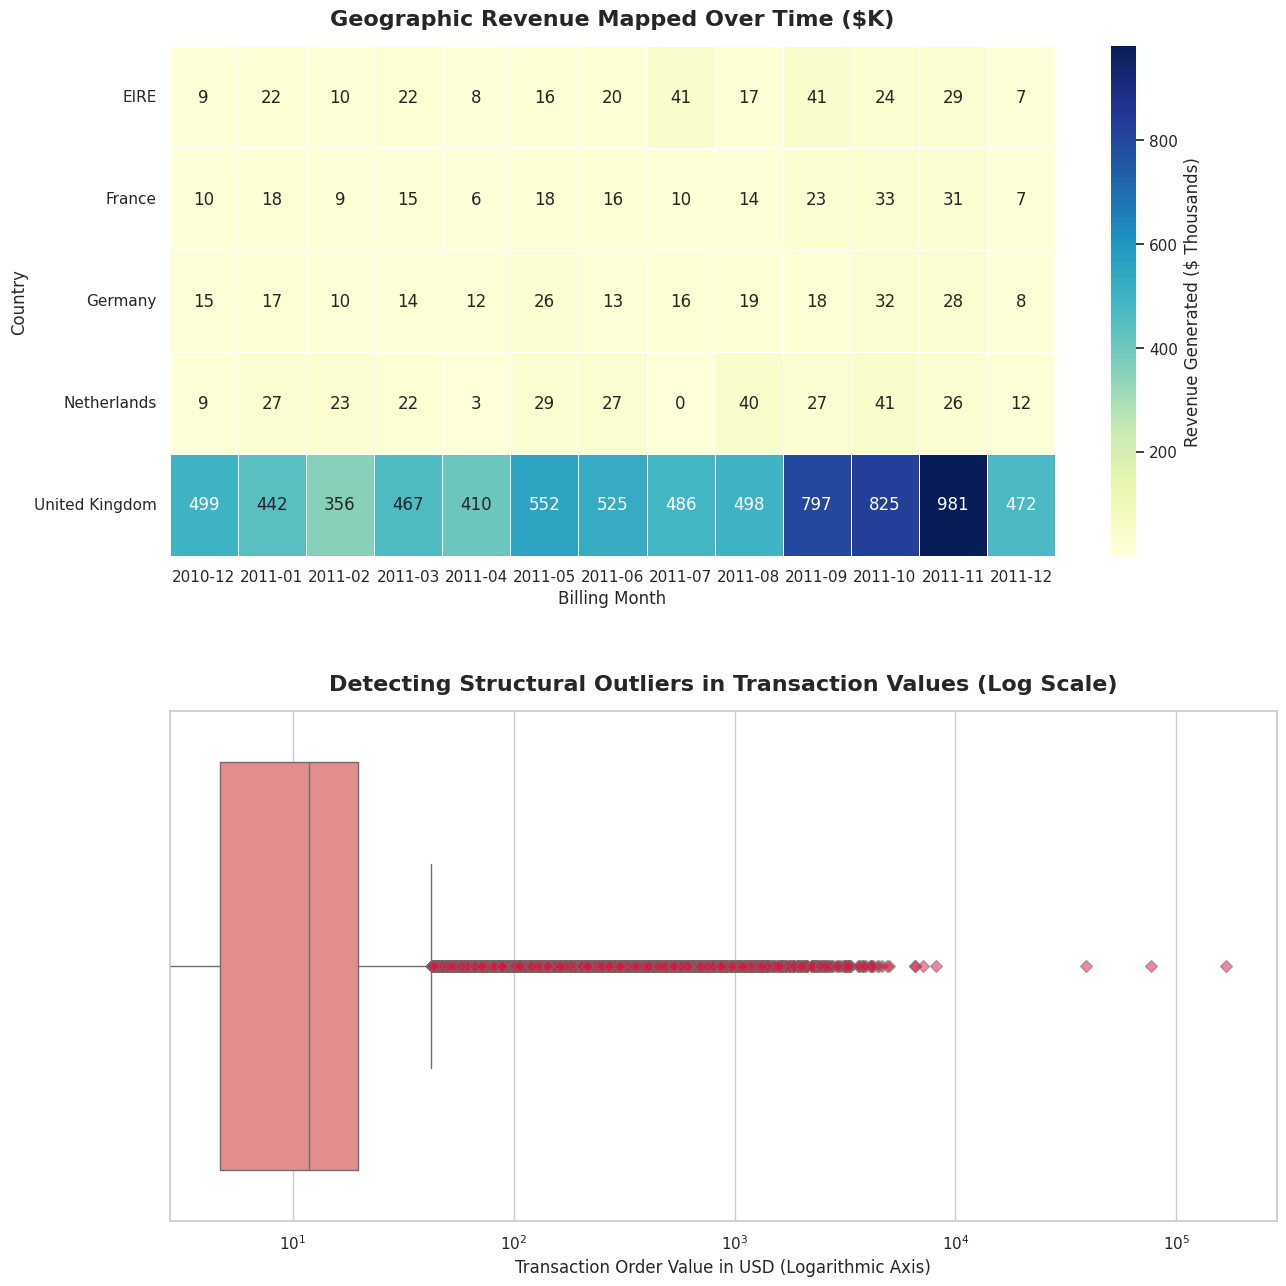


--- The 3 Largest Outlier Transactions Found ---
InvoiceNo                    Description  Quantity  UnitPrice  TotalSpend        Country
   581483    PAPER CRAFT , LITTLE BIRDIE     80995       2.08    168469.6 United Kingdom
   541431 MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04     77183.6 United Kingdom
   556444 PICNIC BASKET WICKER 60 PIECES        60     649.50     38970.0 United Kingdom


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the plotting layout side-by-side or stacked cleanly
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))
sns.set_theme(style="whitegrid")

# --- GRAPH 1: COUNTRY ORDERS BY TIME OF THE MONTH (HEATMAP) ---
# Create a pivot table of the top 5 countries vs months
country_spend = df_sales.groupby('Country')['TotalSpend'].sum()
top_5_countries_list = country_spend.nlargest(5).index.tolist()

pivot_trends = df_sales[df_sales['Country'].isin(top_5_countries_list)].pivot_table(
    index='Country',
    columns='InvoiceMonth',
    values='TotalSpend',
    aggfunc='sum'
).fillna(0)

# Scale by thousands ($K) for cleaner heatmap annotations
pivot_trends_k = pivot_trends / 1000

sns.heatmap(
    pivot_trends_k,
    cmap='YlGnBu',
    annot=True,
    fmt=".0f",
    linewidths=.5,
    ax=ax1,
    cbar_kws={'label': 'Revenue Generated ($ Thousands)'}
)
ax1.set_title('Geographic Revenue Mapped Over Time ($K)', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Billing Month', fontsize=12)
ax1.set_ylabel('Country', fontsize=12)


# --- GRAPH 2: OUTLIER DETECTION (BOXPLOT + HISTOGRAM) ---
# We use a logarithmic scale on the X-axis because the outliers are SO massive,
# a regular scale would crush the normal orders into a tiny invisible line!
sns.boxplot(
    x=df_sales['TotalSpend'],
    ax=ax2,
    color='lightcoral',
    flierprops=dict(markerfacecolor='crimson', marker='D', markersize=6, alpha=0.5)
)
ax2.set_xscale('log') # Log scale handles extreme disparities beautifully

ax2.set_title('Detecting Structural Outliers in Transaction Values (Log Scale)', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('Transaction Order Value in USD (Logarithmic Axis)', fontsize=12)

plt.tight_layout(pad=4.0)
plt.show()

# --- Print the Raw Top Outlier Data to verify the graph values ---
print("\n--- The 3 Largest Outlier Transactions Found ---")
print(df_sales.nlargest(3, 'TotalSpend')[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'TotalSpend', 'Country']].to_string(index=False))

In [22]:
# Print the top 3 highest revenue lines to see who our "whales" are
print("--- Absolute Top 3 Largest Single Transactions ---")
print(df_sales.nlargest(3, 'TotalSpend')[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'TotalSpend', 'Country']])

--- Absolute Top 3 Largest Single Transactions ---
       InvoiceNo                     Description  Quantity  UnitPrice  \
540421    581483     PAPER CRAFT , LITTLE BIRDIE     80995       2.08   
61619     541431  MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04   
222680    556444  PICNIC BASKET WICKER 60 PIECES        60     649.50   

        TotalSpend         Country  
540421    168469.6  United Kingdom  
61619      77183.6  United Kingdom  
222680     38970.0  United Kingdom  


In [23]:
# 1. Define a reasonable wholesale cutoff (e.g., individual lines over $1,500)
# This removes the extreme bulk anomalies but keeps 99.9% of your standard shoppers
cutoff = 1500
df_typical_sales = df_sales[df_sales['TotalSpend'] <= cutoff]

# 2. Check the "Before vs After" average order value
old_avg = df_sales['TotalSpend'].mean()
new_avg = df_typical_sales['TotalSpend'].mean()

print("=============================================")
print("          OUTLIER REMOVAL VERIFICATION       ")
print("=============================================")
print(f"Original average transaction value:  ${old_avg:.2f}")
print(f"Typical customer average value:      ${new_avg:.2f}")
print(f"Total extreme wholesale rows moved:  {len(df_sales) - len(df_typical_sales)}")
print("=============================================")

          OUTLIER REMOVAL VERIFICATION       
Original average transaction value:  $22.39
Typical customer average value:      $20.69
Total extreme wholesale rows moved:  156


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PRODUCTION PIPELINE SUMMARY ---

# 1. Clean Missing Values
df_clean = df.dropna(subset=['CustomerID'])

# 2. Split Pipelines (Sales vs Returns)
df_sales = df_clean[df_clean['Quantity'] > 0].copy()
df_returns = df_clean[df_clean['Quantity'] < 0].copy()

# 3. Feature Engineering
df_sales['InvoiceDate'] = pd.to_datetime(df_sales['InvoiceDate'])
df_sales['TotalSpend'] = df_sales['Quantity'] * df_sales['UnitPrice']
df_sales['InvoiceMonth'] = df_sales['InvoiceDate'].dt.to_period('M').astype(str)

# 4. Filter Out Extreme Structural Outliers (Wholesale Cutoff)
df_typical_sales = df_sales[df_sales['TotalSpend'] <= 1500].copy()

# 5. Customer Aggregation (LTV Database)
customer_revenue = df_typical_sales.groupby('CustomerID')['TotalSpend'].sum().reset_index()
customer_revenue = customer_revenue.rename(columns={'TotalSpend': 'TotalCustomerSpend'})

print("✅ End-to-End Analytics Pipeline Successfully Executed!")
print(f"Final Cleaned Dataset Size for Customer Profiling: {df_typical_sales.shape[0]:,} rows")

✅ End-to-End Analytics Pipeline Successfully Executed!
Final Cleaned Dataset Size for Customer Profiling: 397,768 rows


In [25]:
# Save the typical consumer sales data to a permanent CSV file
df_typical_sales.to_csv('cleaned_ecommerce_sales.csv', index=False)

# Save your grouped customer profile database to a separate CSV file
customer_revenue.to_csv('customer_lifetime_value_profiles.csv', index=False)

print("💾 Files successfully written to your local Colab directory!")

💾 Files successfully written to your local Colab directory!


In [26]:
# 1. Establish the "snapshot date" (one day after the absolute last purchase in the dataset)
snapshot_date = df_typical_sales['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2. Group by CustomerID and calculate Recency, Frequency, and Monetary metrics
rfm = df_typical_sales.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency: Days since last order
    'InvoiceNo': 'nunique',                                  # Frequency: Number of unique orders
    'TotalSpend': 'sum'                                      # Monetary: Total spend
}).reset_index()

# 3. Clean up column names
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("--- RFM Features Successfully Engineered ---")
print(rfm.head())

--- RFM Features Successfully Engineered ---
   CustomerID  Recency  Frequency  Monetary
0     12347.0        2          7   4310.00
1     12348.0       75          4   1797.24
2     12349.0       19          1   1757.55
3     12350.0      310          1    334.40
4     12352.0       36          8   2506.04


In [27]:
import numpy as np

# 1. Score Recency (Lower days = Higher score of 5)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# 2. Score Frequency & Monetary (Higher values = Higher score of 5)
# We use rank(method='first') for frequency because many customers have identical low order counts
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])

# 3. Create a combined segment label map
def label_segment(df):
    r = int(df['R_Score'])
    f = int(df['F_Score'])

    if (r >= 4) and (f >= 4):
        return 'Champions (Top Tier)'
    elif (r >= 3) and (f >= 3):
        return 'Loyal Customers'
    elif (r >= 4) and (f <= 2):
        return 'Recent New Buyers'
    elif (r <= 2) and (f >= 4):
        return 'Can\'t Lose Them (At Risk)'
    elif (r <= 2) and (f <= 2):
        return 'Lost / Hibernating'
    else:
        return 'Average Mid-Tier'

rfm['Segment'] = rfm.apply(label_segment, axis=1)

# 4. Count how many customers fall into each bucket
print("=============================================")
print("          CUSTOMER SEGMENT COUNTS            ")
print("=============================================")
print(rfm['Segment'].value_value_counts() if hasattr(rfm['Segment'], 'value_value_counts') else rfm['Segment'].value_counts())
print("=============================================")

          CUSTOMER SEGMENT COUNTS            
Segment
Champions (Top Tier)         1137
Lost / Hibernating           1062
Loyal Customers               818
Average Mid-Tier              721
Recent New Buyers             320
Can't Lose Them (At Risk)     276
Name: count, dtype: int64


/tmp/ipykernel_1267/2740371813.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


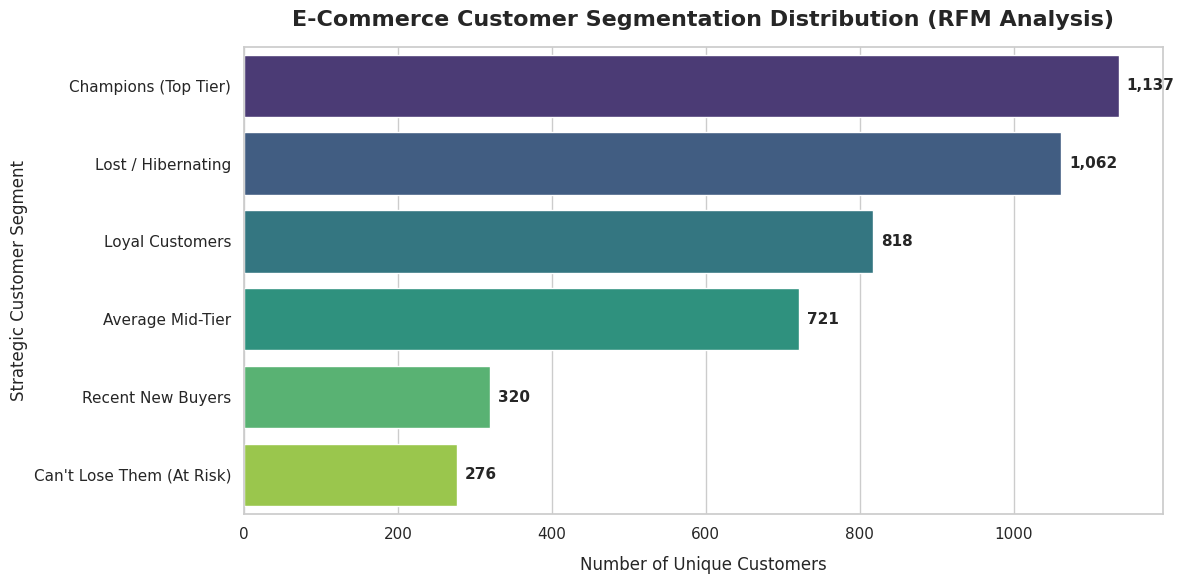

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the order of segments for a clean layout
segment_order = rfm['Segment'].value_counts().index

# 2. Initialize the chart layout
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Create a horizontal bar plot for readability
ax = sns.countplot(
    y='Segment',
    data=rfm,
    order=segment_order,
    palette='viridis'
)

# 4. Add data labels to the end of each bar automatically
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 10,
        p.get_y() + p.get_height()/2,
        f'{int(width):,}',
        va='center',
        fontsize=11,
        fontweight='bold'
    )

# 5. Add professional titles and formatting
plt.title('E-Commerce Customer Segmentation Distribution (RFM Analysis)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Unique Customers', fontsize=12, labelpad=10)
plt.ylabel('Strategic Customer Segment', fontsize=12)
plt.tight_layout()

# 6. Show the chart
plt.show()

In [29]:
# Save the final engineered RFM dataset to a permanent file
rfm.to_csv('ecommerce_customer_rfm_segments.csv', index=False)
print("💾 Upgraded RFM Profiles saved successfully!")

💾 Upgraded RFM Profiles saved successfully!
